In [1]:
import pandas as pd
import numpy as np
import json
import os 
import geopandas as gpd
from shapely.geometry import Point

from pdfs_to_text import pdfs_downloader, pdfs_preprocessing

# Downloading PDFs

In the first notebooks, we obtained the information about building plans and the links to the respective PDFs. In this notebook, you will see how to use the function that takes as input that metadata and downloads all PDFs.

First, read the metadata:

In [2]:
filename = '../data/raw/geoservices_results/map-data.jsonl'

In [3]:
data = []
buffer = ""
with open(filename, 'r', encoding='utf-8') as file:
    for line in file:
        line = line.strip()
        if line:  # Add line to buffer
            buffer += line
            # Check if this is the end of a JSON object
            if line.endswith("}"):
                try:
                    data.append(json.loads(buffer))
                    buffer = ""  # Reset buffer after successful parse
                except json.JSONDecodeError as e:
                    print(f"Error decoding JSON object: {buffer}")
                    print(f"Error: {e}")
                    buffer = ""  # Reset buffer to skip the problematic object


In [4]:
# Define the folder path
flooding_folder_path = '../data/raw/flood_data/'

# Initialize an empty GeoDataFrame
flooding_gdf = gpd.GeoDataFrame()

# Loop through all files in the folder
for file_name in os.listdir(flooding_folder_path):
    if file_name.endswith('.geojson'):
        file_path = os.path.join(flooding_folder_path, file_name)
        print(file_path)

        flood_individual_gdf = gpd.read_file(file_path)
        flooding_gdf = pd.concat([flooding_gdf, flood_individual_gdf], ignore_index=True)

../data/raw/flood_data/highrisk.geojson
../data/raw/flood_data/lowrisk.geojson
../data/raw/flood_data/midrisk.geojson


In [5]:
bavaria_regions_gdf = gpd.read_file('../data/raw/bavaria_regions/bav18.geojson')

In [6]:
data = pd.DataFrame(data)

In [7]:
data['Easting'] = data['BoundingBox'].apply(lambda x: x['Easting'])
data['Northing'] = data['BoundingBox'].apply(lambda x: x['Northing'])

In [8]:
# Convert to a GeoDataFrame
data['geometry'] = data.apply(lambda row: Point(row['Easting'], row['Northing']), axis=1)
gdf = gpd.GeoDataFrame(data, geometry='geometry', crs=3857)

In [9]:
gdf['id'] = gdf.index + 1

In [10]:
bp_with_floods = gdf.sjoin(flooding_gdf, how="left")

In [11]:
bp_with_floods['flooding_risk'] = bp_with_floods['IMPORTDATE'].apply(lambda x: 'has_flooding_risk' if not pd.isnull(x) else 'no_flood_risk')

In [12]:
bp_with_floods.drop(columns=['index_right'], inplace=True)

In [13]:
bp_with_floods = bp_with_floods.sjoin(bavaria_regions_gdf, how="left")

In [14]:
duplicated_rows = bp_with_floods[bp_with_floods.duplicated(subset = 'id', keep=False)]


In [15]:
bp_with_floods['date'] = pd.to_datetime(bp_with_floods['Datum des Inkrafttretens'])

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17668\2712379896.py:1: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  bp_with_floods['date'] = pd.to_datetime(bp_with_floods['Datum des Inkrafttretens'])


<Axes: xlabel='date'>

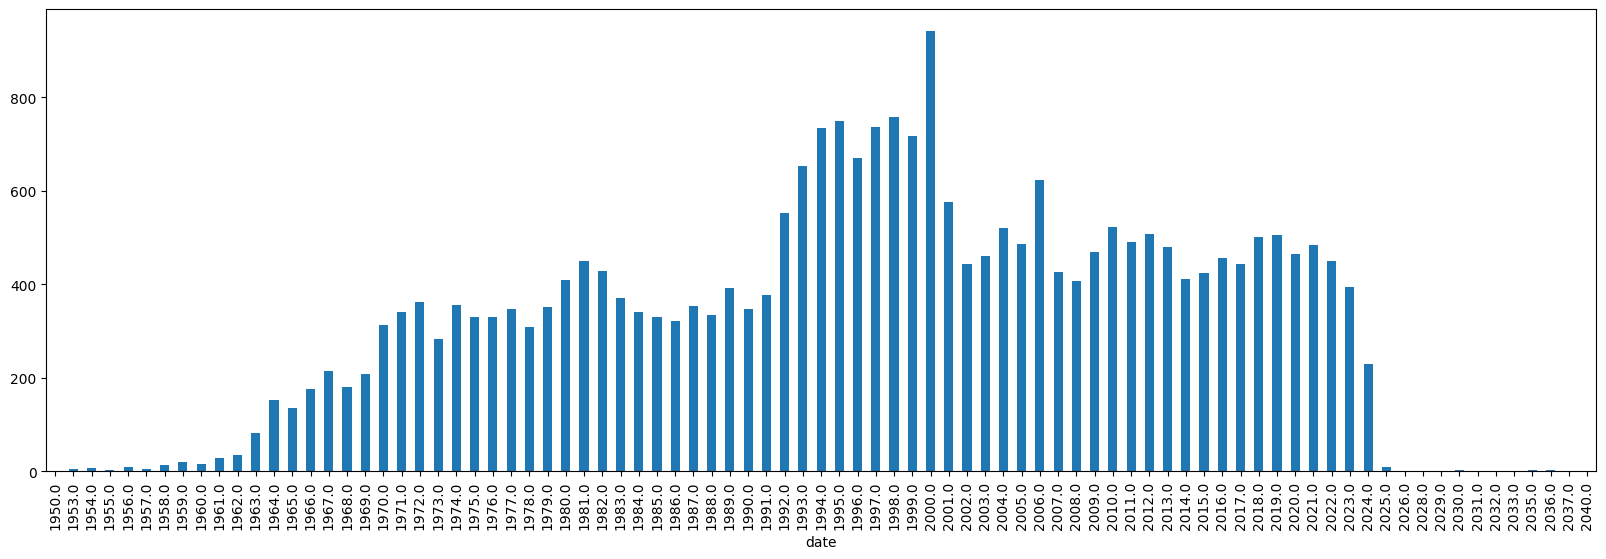

In [16]:
bp_with_floods['date'].groupby(bp_with_floods["date"].dt.year).count().plot(kind="bar", figsize=(20, 6))

In [17]:
bp_with_floods['bplan_date_category'] = bp_with_floods['date'].apply(lambda x: 'old_bplan' if x < pd.Timestamp(2011, 12, 31) else 'new_bplan')

In [18]:
bp_final_data = bp_with_floods[['id', 'bplan_date_category', 'flooding_risk', 'ROR', 'URL des Rasterbildes', 'URL zur Legende',
       'URL der textlichen Festsetzung', 'geometry']]

In [19]:
#sample_final_data = bp_final_data.groupby(['old_bplan', 'flooding_risk', 'ROR']).apply(lambda x: x.sample(min(len(x), 5)))

In [20]:
#sample_final_data.reset_index(drop=True, inplace=True)

In [21]:
bp_final_data.to_file('../data/proc/building_plans/building_plans_metadata.geojson', driver='GeoJSON')